In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from rdkit import Chem
from utils.cleaning import *

# define path ensuring it is from the notebook position
MAIN_DIR = Path().resolve().parent.parent
PATH_DATA = MAIN_DIR / 'data' / 'processed'
PATH_PLOTS = MAIN_DIR / 'docs' / 'src'
PATH_CLEANED = MAIN_DIR / 'data' / 'cleaned'

✓ Plot saved to: C:\Users\aless\Desktop\toxicity-prediction\docs\src\split_distribution.png
Train: (5169, 1817), Valid: (738, 1817), Test: (1478, 1817)


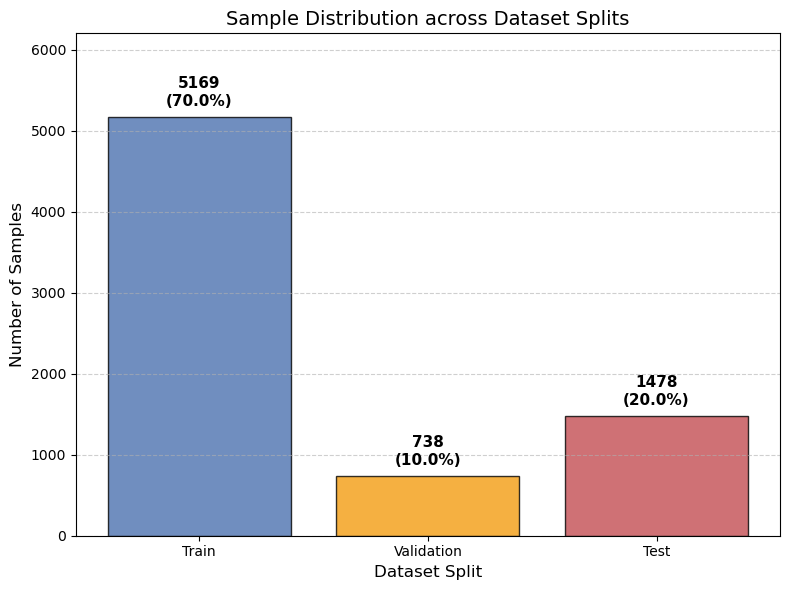

In [2]:
train = pd.read_csv(PATH_DATA / 'train.csv')
valid = pd.read_csv(PATH_DATA / 'valid.csv')
test  = pd.read_csv(PATH_DATA / 'test.csv')
plot_samples_distribution(train, valid, test, save_dir=PATH_PLOTS)

print(f"Train: {train.shape}, Valid: {valid.shape}, Test: {test.shape}")

## 1. Data Cleaning
Data cleaning is a crucial step in the data analysis process.
It involves :
- (Standardizing data formats, just done during collection).
- Removing or correcting inaccurate records from a dataset.
- Handling missing data.
- Removing duplicates.


## 1.0 Small preprocess, adding rdkit molecule column
To facilitate future processing, we will add a column containing the rdkit molecule objects corresponding to the SMILES strings in the 'SMILES' column. This will allow us to easily perform various operations on the molecules later on.

In [3]:
dfs = {'train': train, 'valid': valid, 'test': test}

def process_dataframes(dfs, function, verbose=False, *args, **kwargs):
    """
    Applies a given function to each DataFrame in the dictionary.
    """
    dfs = dfs.copy()
    for k, df in dfs.items():
        if verbose:
            print(f"Processing {k} set:")
        dfs[k] = function(df, *args, **kwargs)
    return dfs

In [4]:
process_dataframes(dfs, lambda df: display(df.head()), verbose=True)

Processing train set:


,Drug_ID,Drug,Y,canonical_smiles,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,...,mordred_SRW10,mordred_TSRW10,mordred_MW,mordred_AMW,mordred_WPath,mordred_WPol,mordred_Zagreb1,mordred_Zagreb2,mordred_mZagreb1,mordred_mZagreb2
0,"Isothiocyanic acid, p-bromophenyl ester",S=C=Nc1ccc(Br)cc1,2.729,S=C=Nc1ccc(Br)cc1,2.996028,261.439525,7.397341,5.042827,7.445321,4.825699,...,8.651899,38.682184,212.924782,15.208913,127,10,44.0,47.0,3.722222,2.416667
1,"Benzene, bromo-",Brc1ccccc1,1.765,Brc1ccccc1,3.021465,134.107370,5.112884,3.764716,5.350712,3.393847,...,8.124151,33.544698,155.957462,12.996455,42,5,30.0,31.0,2.361111,1.666667
2,"2-Propenoic acid, 2-phenoxyethyl ester",C=CC(=O)OCCOc1ccccc1,1.569,C=CC(=O)OCCOc1ccccc1,2.162143,292.660771,10.225768,7.810167,7.810167,6.825699,...,8.768574,43.860335,192.078644,7.387640,379,14,60.0,63.0,4.722222,3.416667
3,"2-Propenal, phenylhydrazone (9CI)",C=CC=NNc1ccccc1,2.320,C=CC=NNc1ccccc1,2.511976,238.999463,7.941311,6.195772,6.195772,5.431852,...,8.491465,39.504541,146.084398,6.956400,182,10,46.0,48.0,3.361111,2.750000
4,"Benzene, ethenyl-",C=Cc1ccccc1,1.319,C=Cc1ccccc1,2.991047,162.653001,5.819991,4.671208,4.671208,3.931852,...,8.298291,35.247635,104.062600,6.503913,64,7,34.0,36.0,2.611111,2.000000


Processing valid set:


,Drug_ID,Drug,Y,canonical_smiles,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,...,mordred_SRW10,mordred_TSRW10,mordred_MW,mordred_AMW,mordred_WPath,mordred_WPol,mordred_Zagreb1,mordred_Zagreb2,mordred_mZagreb1,mordred_mZagreb2
0,"Acetic acid, ((6-(4-chlorophenoxy)-4-pyrimidin...",CC(C)=NNC(=O)CSc1cc(Oc2ccc(Cl)cc2)ncn1,2.892,CC(C)=NNC(=O)CSc1cc(Oc2ccc(Cl)cc2)ncn1,1.927309,702.877994,16.656490,12.615559,14.187984,11.024877,...,9.624369,56.332522,350.060424,9.212116,1456,28,110.0,120.0,7.916667,5.166667
1,"Acetic acid, ((6-(4-methylphenoxy)-4-pyrimidin...",Cc1ccc(Oc2cc(SCC(=O)NN)ncn2)cc1,2.800,Cc1ccc(Oc2cc(SCC(=O)NN)ncn2)cc1,2.016823,589.179957,14.372033,10.867731,11.684227,9.669035,...,9.529012,52.737762,290.083747,8.531875,944,25,96.0,106.0,6.555556,4.583333
2,"Acetic acid, ((6-phenoxy-4-pyrimidinyl)thio)-,...",NNC(=O)CSc1cc(Oc2ccccc2)ncn1,3.099,NNC(=O)CSc1cc(Oc2ccccc2)ncn1,2.007826,550.435464,13.501789,9.945081,10.761578,9.275188,...,9.424726,51.342509,276.068097,8.905422,812,23,90.0,99.0,5.694444,4.416667
3,"Acetic acid, ((6-(4-fluorophenoxy)-4-pyrimidin...",NNC(=O)CSc1cc(Oc2ccc(F)cc2)ncn1,2.867,NNC(=O)CSc1cc(Oc2ccc(F)cc2)ncn1,2.016823,594.266123,14.372033,10.245695,11.062192,9.669035,...,9.529012,52.737762,294.058675,9.485764,944,25,96.0,106.0,6.555556,4.583333
4,"Acetic acid, ((6-(4-chlorophenoxy)-4-pyrimidin...",NNC(=O)CSc1cc(Oc2ccc(Cl)cc2)ncn1,2.589,NNC(=O)CSc1cc(Oc2ccc(Cl)cc2)ncn1,2.016823,594.266123,14.372033,10.245695,11.818121,9.669035,...,9.529012,52.737762,310.029124,10.000939,944,25,96.0,106.0,6.555556,4.583333


Processing test set:


,Drug_ID,Drug,Y,canonical_smiles,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,...,mordred_SRW10,mordred_TSRW10,mordred_MW,mordred_AMW,mordred_WPath,mordred_WPol,mordred_Zagreb1,mordred_Zagreb2,mordred_mZagreb1,mordred_mZagreb2
0,"1,3,4-Thiadiazole, 2-amino-",Nc1nncs1,2.602,Nc1nncs1,3.049648,112.353618,4.405777,2.957376,3.773873,2.893847,...,7.788626,44.534727,101.004768,11.222752,26,2,26.0,27.0,2.111111,1.416667
1,Not Available,CNC(=O)Nc1nnc(C(C)(C)C)s1,2.030,CNC(=O)Nc1nnc(C(C)(C)C)s1,2.737885,328.327424,10.767585,8.710924,9.527420,6.430870,...,9.307376,58.856052,214.088832,7.646030,323,16,68.0,75.0,6.645833,3.083333
2,"Phosphorodithioic acid, O,O-dimethyl S-((5-met...",COc1nnc(CSP(=S)(OC)OC)s1,2.930,COc1nnc(CSP(=S)(OC)OC)s1,2.525110,351.146248,11.311555,8.498237,11.842154,7.131470,...,9.266815,59.841185,285.966942,10.998729,407,18,70.0,78.0,6.284722,3.625000
3,"Phosphorodithioic acid, O,O-diethyl S-((5-meth...",CCOP(=S)(OCC)SCc1nnc(OC)s1,3.966,CCOP(=S)(OCC)SCc1nnc(OC)s1,2.536979,377.847238,12.725768,9.912451,13.256368,8.131470,...,9.347054,62.299847,313.998242,9.812445,579,20,78.0,86.0,6.784722,4.125000
4,"Phosphorothioic acid, O,O-diethyl S-((5-methox...",CCOP(=O)(OCC)SCc1nnc(OC)s1,4.116,CCOP(=O)(OCC)SCc1nnc(OC)s1,2.536979,377.357013,12.725768,9.912451,12.439871,8.131470,...,9.347054,62.299847,298.021086,9.313159,579,20,78.0,86.0,6.784722,4.125000


{'train': None, 'valid': None, 'test': None}

In [5]:
dfs = process_dataframes(dfs, add_molecule_column)
process_dataframes(dfs, lambda d: print(f"\tShape: {d.shape}"), verbose=True)

Processing train set:
	Shape: (5169, 1818)
Processing valid set:
	Shape: (738, 1818)
Processing test set:
	Shape: (1478, 1818)


{'train': None, 'valid': None, 'test': None}

## 1.1 Ensure Data Consistency
Ensure that the collection process has been consistent across all data points. This includes:
- Check for invalid SMILES
- Check for missing values in the target variable (toxicity label `Y`)
- Check for inconsistencies in the data and target relation (same molecule with different toxicity label)
- Handle missing data appropriately, either by imputation or by removing the affected records
- Handle duplicates by removing them


## 1.1 Invalid Smiles
Check for molecules that rdkit cannot parse and remove them.

In [6]:
dfs = process_dataframes(dfs, handle_invalid_smiles, verbose=True)

Processing train set:
Number of invalid SMILES: 0
Processing valid set:
Number of invalid SMILES: 0
Processing test set:
Number of invalid SMILES: 0


## 1.2 Check global missing Values
Check for missing values and handle them appropriately, either by imputation or by removing the affected records.

In [7]:
_ = process_dataframes(dfs, check_missing_values, verbose=True)

Processing train set:
No missing values found in any column.
Processing valid set:
No missing values found in any column.
Processing test set:
No missing values found in any column.


> There are no missing values in the dataset.

## 1.3 Check for Inconsistencies

### in the data and target relation (same molecule with different toxicity labels)
Check for cases where the same molecule (same SMILES string) has different toxicity labels in the dataset. This could indicate errors in the data collection process and should be investigated further.

In [8]:
_ = process_dataframes(dfs, check_mol_target_inconsistencies, verbose=True, smiles_col='canonical_smiles', target_col='Y', show_lines=False)

Processing train set:
Found 15 inconsistent SMILES with multiple toxicity labels
Processing valid set:
Found 5 inconsistent SMILES with multiple toxicity labels
Processing test set:
Found 10 inconsistent SMILES with multiple toxicity labels


> We decided to keep these cases in the dataset, as they may represent true variability in the toxicity of the molecule under different conditions or in different assays. However, we will document these cases and consider them during model training and evaluation.

### salts stripping
Check for the presence of salts in the SMILES strings and remove them if necessary. Salts can introduce noise into the dataset and may not be relevant for toxicity prediction. Removing salts can help to improve the quality of the data and the performance of the model.

In [9]:
dfs = process_dataframes(dfs, strip_salts_and_report, verbose=True)

Processing train set:
	Found and stripped salts in 0 molecules.
Processing valid set:
	Found and stripped salts in 0 molecules.
Processing test set:
	Found and stripped salts in 0 molecules.


## 1.4 Handle Duplicates
Check for duplicate records in the dataset and remove them to ensure that each molecule is represented only once in the dataset. This will help to prevent bias in the model training process and ensure that the model learns from unique examples.

In [10]:
dfs = process_dataframes(dfs, remove_duplicates, verbose=True)

Processing train set:
	Removed 0 duplicate molecules.
Processing valid set:
	Removed 0 duplicate molecules.
Processing test set:
	Removed 0 duplicate molecules.


## 2. Export Cleaned Data
After cleaning the data, export the cleaned dataset to a new file (e.g., CSV or Parquet) for use in the next steps of the analysis. This will allow you to easily load the cleaned data for model training and evaluation.

In [11]:
if not PATH_CLEANED.exists():
    PATH_CLEANED.mkdir(parents=True, exist_ok=True)

for k, df in dfs.items():
    print(f"Exporting {k} set with shape {df.shape} to {PATH_CLEANED / f'{k}.csv'}")
    df.to_csv(PATH_CLEANED / f'{k}.csv', index=False)

Exporting train set with shape (5169, 1818) to C:\Users\aless\Desktop\toxicity-prediction\data\cleaned\train.csv
Exporting valid set with shape (738, 1818) to C:\Users\aless\Desktop\toxicity-prediction\data\cleaned\valid.csv
Exporting test set with shape (1478, 1818) to C:\Users\aless\Desktop\toxicity-prediction\data\cleaned\test.csv
